In [1]:
%pip install matplotlib requests moviepy


Note: you may need to restart the kernel to use updated packages.


# V34b — fixed-core stochastic-seed system audit

Keep the V14a morphology, V17a D4 readout, V30a transport, and V31 local
feature update frozen. Sixteen new marker and mask histories test image
quality and agreement with a translated V14a reference. The first four
also test paired D4 paths and marker removal. A separate history tests
age-256 persistence. The live cell is identical across every random draw;
only the local scalar marker varies. The evaluator shifts the target by
the one-cell even-grid registration offset and reports the unshifted score.

Upload V14a, V17a, V30a, and the passing V34a archive. Run on CUDA.


In [2]:
#@title Version and artifact contract
VERSION = 'V34b'
SLUG = 'v34b_fixed_core_stochastic_seed_system_audit'
USER_AGENT = 'Cells2Pixels V34b'
PREREQUISITE_NAME = 'v34a_fixed_core_stochastic_seed_artifacts.tar.gz'
PREREQUISITE_DECISION = 'fixed_core_stochastic_seed_mechanics_supported'
TRAINING_MODE = None


In [3]:
#@title Remote GPU setup, sharp source artifacts, and lizard target
from io import BytesIO
from pathlib import Path
import hashlib
import importlib.util
import json
import os
import random
import subprocess
import sys
import tarfile
import time

WORKSPACE_ROOT = Path('/workspace') if Path('/workspace').is_dir() else Path.cwd()
V14A_NAME = 'v14a_cells2pixels_lizard_reference_artifacts.tar.gz'
V17A_NAME = 'v17a_frozen_v14a_d4_readout_bridge_artifacts.tar.gz'

def find_artifact(name, version_directory=None):
    candidates = [WORKSPACE_ROOT / name, Path.cwd() / name]
    if version_directory is not None:
        candidates.append(Path.cwd() / 'notebooks-executed' / version_directory / name)
    path = next((candidate.resolve() for candidate in candidates if candidate.is_file()), None)
    if path is None:
        raise FileNotFoundError('Upload ' + name + ' into ' + str(WORKSPACE_ROOT))
    return path

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

def tar_members(path):
    with tarfile.open(path) as archive:
        return {Path(member.name).name: archive.extractfile(member).read()
                for member in archive.getmembers() if member.isfile()}

V14A_PATH = find_artifact(V14A_NAME, 'v14a')
V17A_PATH = find_artifact(V17A_NAME, 'v17a')
v14a_members = tar_members(V14A_PATH)
v17a_members = tar_members(V17A_PATH)
if not {'metrics.json', 'model.pth'} <= v14a_members.keys():
    raise RuntimeError('V14a artifact lacks metrics.json or model.pth')
if not {'metrics.json', 'd4_orbit_decoder.pth'} <= v17a_members.keys():
    raise RuntimeError('V17a artifact lacks metrics.json or d4_orbit_decoder.pth')
v14a_metrics = json.loads(v14a_members['metrics.json'])
v17a_metrics = json.loads(v17a_members['metrics.json'])
if v14a_metrics.get('status') != 'complete':
    raise RuntimeError('The supplied V14a artifact is incomplete')
if v17a_metrics.get('decision') != 'd4_orbit_needed_for_sharp_v14a_state':
    raise RuntimeError('Unexpected V17a decision: ' + str(v17a_metrics.get('decision')))

prerequisite_metrics = None
PREREQUISITE_PATH = None
if PREREQUISITE_NAME is not None:
    prerequisite_version = PREREQUISITE_NAME.split('_', 1)[0]
    PREREQUISITE_PATH = find_artifact(PREREQUISITE_NAME, prerequisite_version)
    prerequisite_members = tar_members(PREREQUISITE_PATH)
    prerequisite_metrics = json.loads(prerequisite_members['metrics.json'])
    if prerequisite_metrics.get('decision') != PREREQUISITE_DECISION:
        raise RuntimeError(
            'Unexpected prerequisite decision: ' +
            str(prerequisite_metrics.get('decision')))

SOURCE_ROOT = WORKSPACE_ROOT / (SLUG + '_source')
SOURCE_ROOT.mkdir(parents=True, exist_ok=True)
(SOURCE_ROOT / 'model.pth').write_bytes(v14a_members['model.pth'])
(SOURCE_ROOT / 'd4_orbit_decoder.pth').write_bytes(
    v17a_members['d4_orbit_decoder.pth'])

repo_candidates = [Path.cwd(), WORKSPACE_ROOT / 'Cells2Pixels']
repo_path = next((path.resolve() for path in repo_candidates
                  if (path / 'models/nca2d.py').is_file()), None)
if repo_path is None:
    repo_path = (WORKSPACE_ROOT / 'Cells2Pixels').resolve()
    subprocess.run([
        'git', 'clone', '--branch', 'isotropic', '--single-branch',
        'https://github.com/IvanLudvig/Cells2Pixels.git', str(repo_path)], check=True)
os.chdir(repo_path)
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

if importlib.util.find_spec('lpips') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips'], check=True)

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import torch.nn.functional as F
from PIL import Image
from lpips import LPIPS
from torch.utils.checkpoint import checkpoint

from losses.invariant_image_loss import InvariantImageLoss
from models.isotropic_lppn import _sine_mlp
from models.nca2d import GrowingNCA
from training.common import normalize_model_grads

if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU runtime is required')
device = torch.device('cuda')
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

TARGET_IMAGE_PATH = Path('data/morphology_png/lizard.png')
if not TARGET_IMAGE_PATH.is_file():
    response = requests.get(
        'https://raw.githubusercontent.com/googlefonts/noto-emoji/43bac1a1272f31cedf0d74c2089fba6c7f952276/png/512/emoji_u1f98e.png',
        headers={'User-Agent': USER_AGENT}, timeout=60)
    response.raise_for_status()
    TARGET_IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
    Image.open(BytesIO(response.content)).convert('RGBA').save(TARGET_IMAGE_PATH)

if file_hash(TARGET_IMAGE_PATH) != v14a_metrics['config']['target_hash']:
    raise RuntimeError('V14a artifact and local target hashes differ')

expected_sources = v14a_metrics['config'].get('repository_sources', {})
actual_sources = {name: file_hash(repo_path / name) for name in (
    'models/nca2d.py', 'losses/invariant_image_loss.py')}
source_mismatches = {name: (expected_sources.get(name), value)
                     for name, value in actual_sources.items()
                     if expected_sources.get(name) != value}
if source_mismatches:
    raise RuntimeError('Repository sources differ from V14a: ' + str(source_mismatches))

alignment_loss = InvariantImageLoss(
    target_path=str(TARGET_IMAGE_PATH), image_size=(256, 256),
    padding=(64, 64), premultiply_alpha=True, aux_type='noaux',
    mirror=True, sharpen=True, l2_weight=1.0,
    include_nca_alpha=True, device=device)
canonical_target = alignment_loss.target_image.detach()
assert canonical_target.shape == (1, 4, 384, 384)
lpips_loss = LPIPS(net='vgg', verbose=False).to(device).eval()
lpips_loss.requires_grad_(False)

OUTPUT_ROOT = WORKSPACE_ROOT / SLUG
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
ARCHIVE_PATH = WORKSPACE_ROOT / (SLUG + '_artifacts.tar.gz')

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rng_state():
    return dict(python=random.getstate(), numpy=np.random.get_state(),
                torch=torch.get_rng_state(), cuda=torch.cuda.get_rng_state_all())

def restore_rng_state(state):
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'])
    torch.cuda.set_rng_state_all(state['cuda'])

print('Repository:', repo_path)
print('V14a:', V14A_PATH, file_hash(V14A_PATH)[:12])
print('V17a:', V17A_PATH, file_hash(V17A_PATH)[:12])
print('Output:', OUTPUT_ROOT)
print('GPU:', torch.cuda.get_device_name(0), '| Torch:', torch.__version__)


/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Repository: /workspace/Cells2Pixels
V14a: /workspace/v14a_cells2pixels_lizard_reference_artifacts.tar.gz 5d8b88b004c5
V17a: /workspace/v17a_frozen_v14a_d4_readout_bridge_artifacts.tar.gz c16185629f3a
Output: /workspace/v34b_fixed_core_stochastic_seed_system_audit
GPU: NVIDIA RTX A2000 12GB | Torch: 2.11.0+cu128


In [4]:
#@title Exact-D4 readout and explicit-mask V14a dynamics
class D4OrbitReadout(torch.nn.Module):
    """V17a ordered four-cell readout projected over all eight D4 views."""

    def __init__(self, channels=32, scale_factor=4, chunk_size=16384):
        super().__init__()
        self.channels = channels
        self.scale_factor = scale_factor
        self.chunk_size = chunk_size
        self._geometry_cache = {}
        corners = torch.tensor([
            [-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=torch.int64)
        identity = torch.eye(2, dtype=torch.int64)
        rotation = torch.tensor([[0, -1], [1, 0]], dtype=torch.int64)
        reflection = torch.tensor([[1, 0], [0, -1]], dtype=torch.int64)
        matrices, current = [], identity
        for _ in range(4):
            matrices.extend([current, current @ reflection])
            current = rotation @ current
        matrices = torch.stack(matrices)
        permutations = []
        for matrix in matrices:
            transformed = corners @ matrix.T
            permutations.append(torch.stack([
                torch.nonzero((transformed == corner).all(-1), as_tuple=False)[0, 0]
                for corner in corners]))
        self.register_buffer('d4_matrices', matrices, persistent=False)
        self.register_buffer(
            'd4_permutations', torch.stack(permutations), persistent=False)
        self.orbit_phi = _sine_mlp(
            5 * channels + 2, 64, 0, 64, 10.0, 10.0)
        self.rho = _sine_mlp(
            channels + 64, 64, 1, 4, 10.0, 10.0)

    def _geometry(self, height, width, device_value, dtype):
        key = (height, width, device_value.type, device_value.index, dtype)
        cached = self._geometry_cache.get(key)
        if cached is not None:
            return cached
        scale = self.scale_factor
        py = ((torch.arange(height * scale, device=device_value, dtype=dtype) + 0.5)
              / scale - 0.5)
        px = ((torch.arange(width * scale, device=device_value, dtype=dtype) + 0.5)
              / scale - 0.5)
        py, px = torch.meshgrid(py, px, indexing='ij')
        y0, x0 = torch.floor(py), torch.floor(px)
        ty, tx = py - y0, px - x0
        neighbor_y = torch.stack([y0, y0, y0 + 1, y0 + 1], -1)
        neighbor_x = torch.stack([x0, x0 + 1, x0, x0 + 1], -1)
        weights = torch.stack([
            (1 - ty) * (1 - tx), (1 - ty) * tx,
            ty * (1 - tx), ty * tx], -1)
        query_yx = torch.stack([ty - 0.5, tx - 0.5], -1)
        indices = (neighbor_y.long().remainder(height) * width
                   + neighbor_x.long().remainder(width))
        result = indices, weights, query_yx
        self._geometry_cache[key] = result
        return result

    def _orbit_descriptor(self, neighbors, interpolated, query_yx):
        batch, point_n, _, channels = neighbors.shape
        descriptor = None
        for matrix, permutation in zip(self.d4_matrices, self.d4_permutations):
            view_neighbors = neighbors.index_select(-2, permutation)
            view_query = query_yx @ matrix.to(query_yx.dtype).T
            view_query = view_query.unsqueeze(0).expand(batch, -1, -1)
            inputs = torch.cat([
                interpolated,
                view_neighbors.reshape(batch, point_n, 4 * channels),
                view_query], -1)
            encoded = self.orbit_phi(inputs)
            descriptor = encoded if descriptor is None else descriptor + encoded
        return descriptor / 8

    def forward(self, state):
        batch, channels, height, width = state.shape
        if channels != self.channels:
            raise ValueError('Expected ' + str(self.channels) + ' channels')
        indices, weights, query_yx = self._geometry(
            height, width, state.device, state.dtype)
        out_height, out_width, _ = indices.shape
        point_n = out_height * out_width
        flat = state.permute(0, 2, 3, 1).reshape(
            batch, height * width, channels)
        neighbors = flat[:, indices.reshape(-1)].reshape(
            batch, point_n, 4, channels)
        interpolated = (
            neighbors * weights.reshape(1, point_n, 4, 1)).sum(-2)
        query_yx = query_yx.reshape(point_n, 2)
        outputs = []
        for start in range(0, point_n, self.chunk_size):
            stop = min(start + self.chunk_size, point_n)
            arguments = (neighbors[:, start:stop], interpolated[:, start:stop],
                         query_yx[start:stop])
            if self.training:
                descriptor = checkpoint(
                    self._orbit_descriptor, *arguments, use_reentrant=False)
            else:
                descriptor = self._orbit_descriptor(*arguments)
            outputs.append(self.rho(torch.cat([
                interpolated[:, start:stop], descriptor], -1)))
        return torch.cat(outputs, 1).reshape(
            batch, out_height, out_width, 4)

def d4_apply(tensor, index):
    transformed = torch.rot90(tensor, index % 4, (-2, -1))
    return transformed.flip(-1) if index >= 4 else transformed

D4_INVERSES = (0, 3, 2, 1, 4, 5, 6, 7)

def make_source_system(train=False):
    model = GrowingNCA(
        channels=32, fc_dim=256, padding='circular', perception_kernels=4,
        update_prob=0.5, device=device, precision=torch.float16).to(device)
    decoder = D4OrbitReadout().to(device)
    model.load_state_dict(torch.load(
        SOURCE_ROOT / 'model.pth', map_location=device, weights_only=True))
    decoder.load_state_dict(torch.load(
        SOURCE_ROOT / 'd4_orbit_decoder.pth', map_location=device,
        weights_only=True))
    model.train(train)
    decoder.train(train)
    return model, decoder

def explicit_step(model, state, update_mask):
    pre_life = model.get_living_mask(state)
    delta, _ = model.adaptation(state)
    proposal = state + delta * update_mask.to(delta.dtype)
    post_life = model.get_living_mask(proposal)
    return proposal * torch.logical_and(pre_life, post_life).to(proposal.dtype)

def render_state(model, decoder, state):
    state_float = state.float()
    raw = decoder(state_float).permute(0, 3, 1, 2)
    state_up = F.interpolate(
        state_float, scale_factor=4, mode='bilinear', align_corners=False)
    living = model.get_living_mask(state_up).to(raw.dtype)
    return raw * living, state_up

def mask_history(seed, age):
    generator = torch.Generator(device='cpu').manual_seed(int(seed))
    return (torch.rand(
        age, 1, 1, 96, 96, generator=generator) < 0.5).to(torch.float32)

def select_target(prediction):
    with torch.no_grad():
        scores = [float((prediction - d4_apply(canonical_target, index)).abs().mean())
                  for index in range(8)]
    index = int(np.argmin(scores))
    return d4_apply(canonical_target, index), index

def image_objective(prediction, state_up, target):
    rgba_l1 = (prediction - target).abs().mean()
    rgba_l2 = (prediction - target).square().mean()
    shape_l1 = (2.0 * state_up[:, 3:4] - target[:, 3:4]).abs().mean()
    shape_l2 = (2.0 * state_up[:, 3:4] - target[:, 3:4]).square().mean()
    perceptual = lpips_loss(
        prediction[:, :3, 64:-64, 64:-64],
        target[:, :3, 64:-64, 64:-64], normalize=True).mean()
    quality = rgba_l1 + rgba_l2 + shape_l1 + shape_l2 + perceptual
    return quality, dict(
        rgba_l1=rgba_l1, rgba_l2=rgba_l2, shape_l1=shape_l1,
        shape_l2=shape_l2, lpips=perceptual)

def scalar_terms(quality, terms):
    return dict(quality=float(quality.detach()),
                **{name: float(value.detach()) for name, value in terms.items()})

def composite_metrics(prediction, state_up, target):
    quality, terms = image_objective(prediction, state_up, target)
    return scalar_terms(quality, terms)

def white_background(rgba):
    value = rgba.detach().cpu().clamp(0, 1)
    return (value[:3] + 1.0 - value[3:4]).permute(1, 2, 0).clamp(0, 1)


In [5]:
#@title D4 group action and cue-conditioned V14a update
probe = torch.arange(25, device=device).reshape(1, 1, 5, 5)
COMPOSE = tuple(tuple(next(k for k in range(8)
                           if torch.equal(d4_apply(d4_apply(probe, g), h),
                                          d4_apply(probe, k)))
                      for g in range(8)) for h in range(8))
assert all(COMPOSE[0][g] == COMPOSE[g][0] == g for g in range(8))
assert all(COMPOSE[D4_INVERSES[g]][g] == 0 for g in range(8))
assert all(COMPOSE[h][COMPOSE[g][k]] == COMPOSE[COMPOSE[h][g]][k]
           for h in range(8) for g in range(8) for k in range(8))

def steered_delta(model, state, gauge):
    canonical = d4_apply(state, D4_INVERSES[gauge])
    delta, _ = model.adaptation(canonical)
    return d4_apply(delta, gauge)

def apply_delta(model, state, delta, mask):
    pre_life = model.get_living_mask(state)
    proposal = state + delta * mask.to(delta.dtype)
    post_life = model.get_living_mask(proposal)
    return proposal * torch.logical_and(pre_life, post_life).to(proposal.dtype)

def steered_step(model, state, mask, gauge):
    return apply_delta(model, state, steered_delta(model, state, gauge), mask)

def paired_errors(model, decoder, masks, gauge, transform, local=False):
    base = d4_apply(model.seed(1, 96, 96), gauge)
    view = d4_apply(base, transform)
    if local:
        base_cue = cue_seed(base, gauge)
        view_cue = transform_cue(base_cue, transform)
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.float16):
        for mask_cpu in masks:
            mask = mask_cpu.to(device)
            if local:
                base, base_cue = local_step(model, base, base_cue, mask)
                view, view_cue = local_step(
                    model, view, view_cue, d4_apply(mask, transform))
            else:
                base = steered_step(model, base, mask, gauge)
                view = steered_step(
                    model, view, d4_apply(mask, transform),
                    COMPOSE[transform][gauge])
        base_image, base_up = render_state(model, decoder, base)
        view_image, _ = render_state(model, decoder, view)
    target = d4_apply(canonical_target, gauge)
    quality = composite_metrics(base_image, base_up, target)
    return dict(
        quality=quality['quality'],
        state_d4=float((view.float() - d4_apply(base.float(), transform)).abs().max()),
        image_d4=float((view_image - d4_apply(base_image, transform)).abs().max()),
        maximum_state_abs=max(float(base.float().abs().max()),
                              float(view.float().abs().max()))), base_image[0].detach().cpu()

def save_panel(rows, path):
    fig, axes = plt.subplots(len(rows), 2, figsize=(7, 3 * len(rows)))
    for ax, (label, image) in zip(axes, rows):
        ax[0].imshow(white_background(
            d4_apply(canonical_target[0], label)).float())
        ax[0].set_title('target gauge ' + str(label))
        ax[1].imshow(white_background(image).float())
        ax[1].set_title('render gauge ' + str(label))
        for item in ax: item.axis('off')
    fig.tight_layout(); fig.savefig(path, dpi=130)
    plt.show(); plt.close(fig)


In [6]:
#@title Single-seed, locally propagated orientation label
def cue_seed(state, gauge):
    cue = torch.zeros(state.shape[0], 8, *state.shape[-2:],
                      device=state.device, dtype=state.dtype)
    cue[:, gauge:gauge + 1] = (state[:, 3:4] > 0).to(state.dtype)
    return cue

def transform_cue(cue, transform):
    output = torch.zeros_like(cue)
    for gauge in range(8):
        output[:, COMPOSE[transform][gauge]] = d4_apply(cue[:, gauge], transform)
    return output

def local_step(model, state, cue, mask):
    # Max-pool transports the label one cell per tick. Each occupied label
    # selects a conjugated local V14a rule; no absolute position enters.
    cue = F.max_pool2d(cue, 3, stride=1, padding=1)
    occupancy = cue.sum(1, keepdim=True)
    if float(occupancy.max()) > 1.0 + 1e-5:
        raise RuntimeError('Overlapping orientation labels need a separate rule')
    delta = torch.zeros_like(state)
    for gauge in range(8):
        if bool(cue[:, gauge].any()):
            delta = delta + cue[:, gauge:gauge + 1] * steered_delta(
                model, state, gauge)
    return apply_delta(model, state, delta, mask), cue

def local_global_gap(model, decoder, masks, gauge):
    global_state = d4_apply(model.seed(1, 96, 96), gauge)
    local_state = global_state.clone()
    cue = cue_seed(local_state, gauge)
    by_age = {}
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.float16):
        for age, mask_cpu in enumerate(masks, 1):
            mask = mask_cpu.to(device)
            global_state = steered_step(model, global_state, mask, gauge)
            local_state, cue = local_step(model, local_state, cue, mask)
            if age in (1, 8, 32, 128):
                by_age[str(age)] = float((local_state.float() - global_state.float()).abs().max())
        image, state_up = render_state(model, decoder, local_state)
    quality = composite_metrics(image, state_up,
                                d4_apply(canonical_target, gauge))['quality']
    return by_age, quality, local_state, cue, image[0].detach().cpu()


In [7]:
#@title Shared, radius-one trainable cue transport
class LearnedTransport(torch.nn.Module):
    """One shared three-parameter rule for all eight regular D4 cue channels."""

    def __init__(self):
        super().__init__()
        self.center_weight = torch.nn.Parameter(torch.tensor(0.0))
        self.neighbor_weight = torch.nn.Parameter(torch.tensor(0.0))
        self.bias = torch.nn.Parameter(torch.tensor(-2.0))
        kernel = torch.ones(8, 1, 3, 3)
        kernel[:, :, 1, 1] = 0
        self.register_buffer('kernel', kernel, persistent=False)

    def logits(self, cue):
        neighbors = F.conv2d(cue.float(), self.kernel, padding=1, groups=8)
        return self.center_weight * cue.float() + self.neighbor_weight * neighbors + self.bias

    def forward(self, cue):
        return (self.logits(cue) > 0).to(cue.dtype)


def truth_table(rule):
    center = torch.tensor([0., 1.], device=device).repeat_interleave(9)
    neighbors = torch.arange(9, device=device).float().repeat(2)
    labels = ((center + neighbors) > 0).float()
    logits = rule.center_weight * center + rule.neighbor_weight * neighbors + rule.bias
    return logits, labels


def transport_mechanics(rule):
    generator = torch.Generator(device='cpu').manual_seed(30017)
    cue = (torch.rand(1, 8, 19, 19, generator=generator) < 0.15).float().to(device)
    base = rule(cue)
    one_step_error = 0.0
    for transform in range(8):
        view = transform_cue(cue, transform)
        actual = rule(view)
        expected = transform_cue(base, transform)
        one_step_error = max(one_step_error, float((actual - expected).abs().max()))
    return one_step_error


In [8]:
#@title Exact local action on frozen V14a perception features
def make_feature_maps(model):
    filters = model.train_filters
    if filters.shape != (4, 3, 3):
        raise RuntimeError('Expected V14a identity, Sobel x/y, Laplacian kernels')
    maps = []
    for gauge in range(8):
        row = []
        for output_kernel in range(4):
            transformed = d4_apply(filters[output_kernel], gauge)
            matches = [(input_kernel, sign) for input_kernel in range(4)
                       for sign in (1, -1)
                       if torch.equal(transformed, sign * filters[input_kernel])]
            if len(matches) != 1:
                raise RuntimeError('Kernel action is not a signed permutation: '
                                   + str((gauge, output_kernel, matches)))
            row.append(matches[0])
        if row[0] != (0, 1) or row[3] != (3, 1):
            raise RuntimeError('Identity or Laplacian is not D4-invariant')
        maps.append(tuple(row))
    return tuple(maps)


def local_feature_delta(model, state, cue, feature_maps):
    # One radius-one perception of the original state. Each active gauge
    # only changes the four local feature slots before frozen pointwise layers.
    batch, channels, height, width = state.shape
    perceived = model.perception(state).reshape(batch, channels, 4, height, width)
    delta = torch.zeros_like(state)
    for gauge in range(8):
        if bool(cue[:, gauge].any()):
            oriented = torch.stack([
                sign * perceived[:, :, input_kernel]
                for input_kernel, sign in feature_maps[gauge]], dim=2)
            oriented = oriented.reshape(batch, 4 * channels, height, width)
            update = model.w2(torch.relu(model.w1(oriented)))
            delta = delta + cue[:, gauge:gauge + 1] * update
    return delta


def local_feature_step(model, state, cue, mask, feature_maps,
                       transport_rule=None):
    cue = (F.max_pool2d(cue, 3, stride=1, padding=1)
           if transport_rule is None else transport_rule(cue))
    if float(cue.sum(1).max()) > 1.0 + 1e-5:
        raise RuntimeError('Multiple labels at a cell need a collision rule')
    delta = local_feature_delta(model, state, cue, feature_maps)
    return apply_delta(model, state, delta, mask), cue


In [9]:
#@title Radius-one orientation decoder for an asymmetric marker seed
# This auxiliary scalar field is part of the initial condition. Values 1, 2,
# and 3 distinguish the core, its right neighbor, and its lower neighbor.
# Their ordered L shape has eight distinct D4 images. The trained V14a state
# remains its original single live cell; markers never enter V14a perception.
CANONICAL_MARKER = torch.zeros(1, 1, 3, 3, device=device)
CANONICAL_MARKER[0, 0, 1, 1] = 1
CANONICAL_MARKER[0, 0, 1, 2] = 2
CANONICAL_MARKER[0, 0, 2, 1] = 3
MARKER_TEMPLATES = tuple(d4_apply(CANONICAL_MARKER, g) for g in range(8))
assert len({tuple(t.flatten().tolist()) for t in MARKER_TEMPLATES}) == 8

def marker_seed(state, gauge=0):
    """Make the registered structured seed; gauge is used only by the audit."""
    canonical = torch.zeros(state.shape[0], 1, *state.shape[-2:],
                            device=state.device, dtype=state.dtype)
    cy, cx = state.shape[-2] // 2, state.shape[-1] // 2
    canonical[:, :, cy, cx] = 1
    canonical[:, :, cy, (cx + 1) % state.shape[-1]] = 2
    canonical[:, :, (cy + 1) % state.shape[-2], cx] = 3
    return d4_apply(canonical, gauge)

def decode_marker(state, marker):
    """Read one radius-one patch at each live seed; use no gauge argument."""
    if marker.shape[0] != state.shape[0] or marker.shape[-2:] != state.shape[-2:]:
        raise ValueError('Marker and NCA state shapes differ')
    padded = F.pad(marker.float(), (1, 1, 1, 1), mode='circular')
    scores = torch.cat([F.conv2d(padded, template.float())
                        for template in MARKER_TEMPLATES], dim=1)
    top, chosen = scores.max(dim=1)
    # An exact marker scores 1^2+2^2+3^2=14; any wrong D4 template
    # scores at most 13. Missing or damaged markers yield no cue.
    center = state[:, 3] > 0
    valid = center & (top >= 13.5)
    cue = F.one_hot(chosen, 8).permute(0, 3, 1, 2).to(state.dtype)
    return cue * valid[:, None].to(state.dtype), scores

def registered_seed(model, gauge):
    state = d4_apply(model.seed(1, 96, 96), gauge)
    marker = marker_seed(model.seed(1, 96, 96), gauge)
    cue, scores = decode_marker(state, marker)
    return state, marker, cue, scores


In [10]:
#@title D4-symmetric random marker distribution and local orientation readout
# The nine marker values are iid U[0,1). No orientation label is sampled.
# Template matching selects one of eight D4-related orientations. An exact
# tie, including the blank symmetric marker, produces no cue.
NOISE_TEMPLATES = torch.stack(MARKER_TEMPLATES).reshape(8, 9).float()
NOISE_MARGIN = 1e-5

def patch_choice(patches):
    scores = patches.reshape(-1, 9).float() @ NOISE_TEMPLATES.T
    top = scores.topk(2, dim=1)
    margins = top.values[:, 0] - top.values[:, 1]
    return top.indices[:, 0], margins

def decode_noise_marker(state, marker):
    if marker.shape[0] != state.shape[0] or marker.shape[-2:] != state.shape[-2:]:
        raise ValueError('Marker and NCA state shapes differ')
    padded = F.pad(marker.float(), (1, 1, 1, 1), mode='circular')
    scores = torch.cat([F.conv2d(padded, t.float()) for t in MARKER_TEMPLATES], 1)
    top = scores.topk(2, dim=1)
    margin = top.values[:, 0] - top.values[:, 1]
    live_core = state[:, 3] > 0
    valid = live_core & (margin > NOISE_MARGIN)
    cue = F.one_hot(top.indices[:, 0], 8).permute(0, 3, 1, 2).to(state.dtype)
    return cue * valid[:, None].to(state.dtype), margin

def random_registered_seed(model, random_seed):
    """Sample local iid noise, then place the one-cell seed at its D4 site.

    Registration matters on a 96x96 even grid: D4 moves the central pixel
    among four sites. The inferred gauge is used only to place that pixel;
    the local rule receives the decoded cue, never this integer.
    """
    generator = torch.Generator(device='cpu').manual_seed(int(random_seed))
    patch = torch.rand(1, 1, 3, 3, generator=generator).to(device)
    choice, margin = patch_choice(patch)
    if float(margin.min()) <= NOISE_MARGIN:
        raise RuntimeError('Ambiguous random patch; use a predeclared new seed')
    gauge = int(choice.item())
    state = d4_apply(model.seed(1, 96, 96), gauge)
    marker = torch.zeros(1, 1, 96, 96, device=device)
    core = torch.nonzero(state[0, 3] > 0, as_tuple=False)
    assert core.shape[0] == 1
    cy, cx = (int(v) for v in core[0])
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            marker[0, 0, (cy + dy) % 96, (cx + dx) % 96] = patch[0, 0, dy + 1, dx + 1]
    cue, _ = decode_noise_marker(state, marker)
    assert float(cue.sum()) == 1 and float(cue[0, gauge].sum()) == 1
    return state, marker, cue, gauge, float(margin.item())


In [11]:
#@title Fixed live core, random local marker, and translation-aware target
def core_site(state):
    sites = torch.nonzero(state[0, 3] > 0, as_tuple=False)
    if state.shape[0] != 1 or sites.shape[0] != 1:
        raise ValueError('Expected one live core in a batch of one')
    return tuple(int(value) for value in sites[0])


def fixed_core_random_seed(model, random_seed):
    """The V14a initial state is identical for every draw, including its site."""
    generator = torch.Generator(device='cpu').manual_seed(int(random_seed))
    patch = torch.rand(1, 1, 3, 3, generator=generator).to(device)
    state = model.seed(1, 96, 96)
    cy, cx = core_site(state)
    marker = torch.zeros(1, 1, 96, 96, device=device)
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            marker[0, 0, (cy + dy) % 96, (cx + dx) % 96] = patch[0, 0, dy + 1, dx + 1]
    cue, _ = decode_noise_marker(state, marker)
    choice, margin = patch_choice(patch)
    if float(margin.item()) <= NOISE_MARGIN or float(cue.sum()) != 1:
        raise RuntimeError('Ambiguous marker; report this seed and stop the audit')
    gauge = int(choice.item())
    if float(cue[0, gauge].sum()) != 1:
        raise RuntimeError('Local readout disagrees with the patch choice')
    return state, marker, cue, gauge, float(margin.item())


def core_displacement(initial_state, gauge):
    """Offset from the rotated V14a reference core to this initial core."""
    reference = d4_apply(model.seed(1, 96, 96), gauge)
    actual_y, actual_x = core_site(initial_state)
    reference_y, reference_x = core_site(reference)
    return actual_y - reference_y, actual_x - reference_x


def target_for_core(initial_state, gauge):
    # One NCA cell corresponds to four render pixels. This is an evaluation
    # alignment, never an input to the local growth rule.
    dy, dx = core_displacement(initial_state, gauge)
    return torch.roll(d4_apply(canonical_target, gauge),
                      (4 * dy, 4 * dx), (-2, -1))


sample 1 of 16; inferred gauge 0
sample 2 of 16; inferred gauge 3
sample 3 of 16; inferred gauge 0
sample 4 of 16; inferred gauge 1
sample 5 of 16; inferred gauge 0
sample 6 of 16; inferred gauge 2
sample 7 of 16; inferred gauge 6
sample 8 of 16; inferred gauge 1
sample 9 of 16; inferred gauge 1
sample 10 of 16; inferred gauge 2
sample 11 of 16; inferred gauge 5
sample 12 of 16; inferred gauge 3
sample 13 of 16; inferred gauge 1
sample 14 of 16; inferred gauge 6
sample 15 of 16; inferred gauge 6
sample 16 of 16; inferred gauge 0


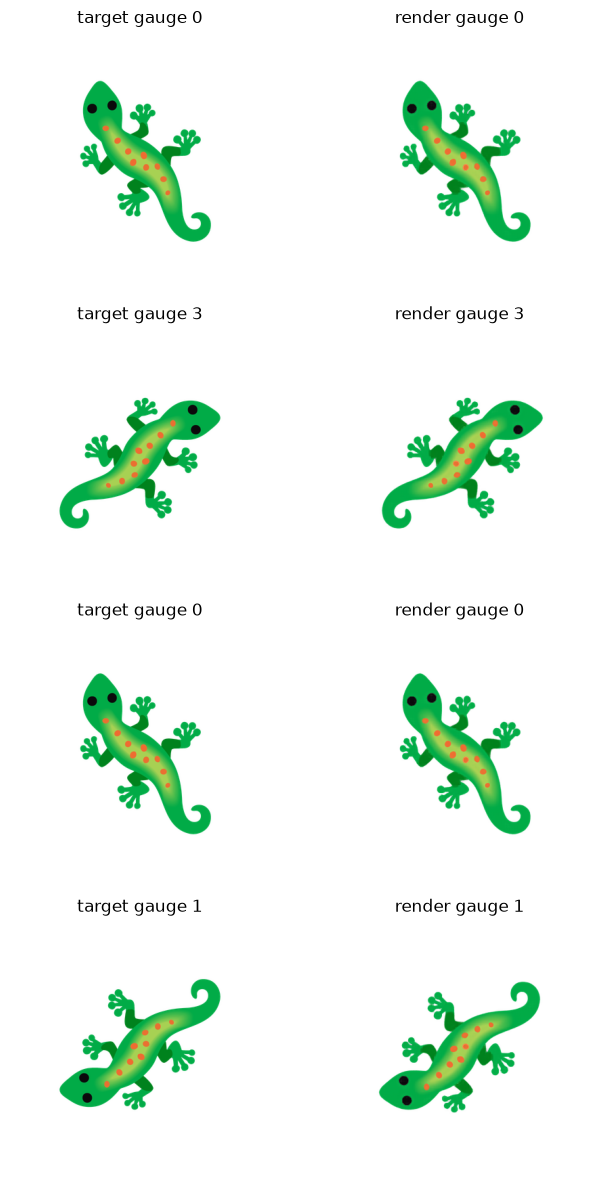

Summary: {'mean_quality': 0.01728991197887808, 'worst_quality': 0.017666876316070557, 'mean_unshifted_quality': 0.13425932684913278, 'reference_gap': 0.0, 'state_d4': 0.0, 'image_d4': 0.001220703125, 'maximum_state_abs': 0.99853515625, 'minimum_blank_ratio': 42.63601228953738, 'long_quality': {'128': 0.017286516726017, '192': 0.017119793221354485, '256': 0.017114991322159767}, 'long_ratio': 0.990355286301746}
Checks: {'finite': True, 'reference': True, 'quality': True, 'd4': True, 'bounded': True, 'marker_causal': True, 'persistence': True} | Decision: fixed_core_stochastic_seed_system_supported
Download: /workspace/v34b_fixed_core_stochastic_seed_system_audit_artifacts.tar.gz


In [12]:
#@title V34b fixed-core image, translated-reference, and paired-path audit
if prerequisite_metrics['decision'] != 'fixed_core_stochastic_seed_mechanics_supported':
    raise RuntimeError('V34a mechanics gate must pass')
transport_path = find_artifact('v30a_learned_local_transport_artifacts.tar.gz', 'v30a')
transport_members = tar_members(transport_path)
if json.loads(transport_members['metrics.json'])['decision'] != 'learned_local_transport_mechanics_supported':
    raise RuntimeError('V30a transport did not pass')
transport_rule = LearnedTransport().to(device).eval()
transport_rule.load_state_dict(torch.load(BytesIO(transport_members['transport.pth']),
                                      map_location=device, weights_only=True))
transport_rule.requires_grad_(False)
model, decoder = make_source_system(train=False)
model.requires_grad_(False); decoder.requires_grad_(False)
feature_maps = make_feature_maps(model)

@torch.no_grad()
def rollout(initial_state, marker, masks, record=(1, 8, 32, 128)):
    state = initial_state.clone()
    cue, _ = decode_noise_marker(state, marker)
    snapshots = {}
    with torch.autocast(device_type='cuda', dtype=torch.float16):
        for age, mask_cpu in enumerate(masks, 1):
            state, cue = local_feature_step(model, state, cue, mask_cpu.to(device),
                                            feature_maps, transport_rule)
            if age in record:
                snapshots[age] = state.clone()
    return state, snapshots

@torch.no_grad()
def source_rollout(initial_state, masks, gauge):
    displacement = core_displacement(initial_state, gauge)
    state = d4_apply(model.seed(1, 96, 96), gauge)
    snapshots = {}
    with torch.autocast(device_type='cuda', dtype=torch.float16):
        for age, mask_cpu in enumerate(masks, 1):
            reference_mask = torch.roll(mask_cpu.to(device),
                                        (-displacement[0], -displacement[1]), (-2, -1))
            state = steered_step(model, state, reference_mask, gauge)
            if age in (1, 8, 32, 128):
                snapshots[age] = torch.roll(state, displacement, (-2, -1))
    return snapshots

@torch.no_grad()
def quality_and_image(state, target):
    with torch.autocast(device_type='cuda', dtype=torch.float16):
        image, up = render_state(model, decoder, state)
    return composite_metrics(image, up, target)['quality'], image, up

rows, panel = [], []
for index in range(16):
    marker_seed, history_seed = 34301 + index, 34401 + index
    initial, marker, cue, gauge, margin = fixed_core_random_seed(model, marker_seed)
    masks = mask_history(history_seed, 128)
    state, snapshots = rollout(initial, marker, masks)
    target = target_for_core(initial, gauge)
    quality, image, up = quality_and_image(state, target)
    unshifted_quality = composite_metrics(
        image, up, d4_apply(canonical_target, gauge))['quality']
    oracle = source_rollout(initial, masks, gauge)
    gaps = {str(age): float((snapshots[age].float() - oracle[age].float()).abs().max())
            for age in (1, 8, 32, 128)}
    pairs = []
    blank_quality = None
    if index < 4:
        panel.append((gauge, image[0].detach().cpu()))
        for transform in (1, 4):
            paired_initial = d4_apply(initial, transform)
            view, _ = rollout(paired_initial, d4_apply(marker, transform),
                              d4_apply(masks, transform))
            view_gauge = COMPOSE[transform][gauge]
            view_target = target_for_core(paired_initial, view_gauge)
            view_quality, view_image, _ = quality_and_image(view, view_target)
            pairs.append(dict(transform=transform, quality=view_quality,
                              state=float((view.float() - d4_apply(state.float(), transform)).abs().max()),
                              image=float((view_image - d4_apply(image, transform)).abs().max())))
        blank, _ = rollout(initial, torch.zeros_like(marker), masks)
        blank_quality, _, _ = quality_and_image(blank, target)
    rows.append(dict(marker_seed=marker_seed, history_seed=history_seed,
                     gauge=gauge, margin=margin, core=core_site(initial),
                     displacement=core_displacement(initial, gauge),
                     quality=quality, unshifted_quality=unshifted_quality,
                     gaps=gaps, pairs=pairs, blank_quality=blank_quality,
                     maximum_state_abs=float(state.float().abs().max())))
    print('sample', index + 1, 'of 16; inferred gauge', gauge)

long_initial, long_marker, _, long_gauge, _ = fixed_core_random_seed(model, 34331)
_, long_snapshots = rollout(long_initial, long_marker, mask_history(34431, 256),
                            record=(128, 192, 256))
long_target = target_for_core(long_initial, long_gauge)
long_quality = {str(age): quality_and_image(long_snapshots[age], long_target)[0]
                for age in (128, 192, 256)}
summary = dict(mean_quality=float(np.mean([r['quality'] for r in rows])),
               worst_quality=max(r['quality'] for r in rows),
               mean_unshifted_quality=float(np.mean([r['unshifted_quality'] for r in rows])),
               reference_gap=max(max(r['gaps'].values()) for r in rows),
               state_d4=max(p['state'] for r in rows for p in r['pairs']),
               image_d4=max(p['image'] for r in rows for p in r['pairs']),
               maximum_state_abs=max([r['maximum_state_abs'] for r in rows] +
                                     [float(s.float().abs().max()) for s in long_snapshots.values()]),
               minimum_blank_ratio=min(r['blank_quality'] / max(r['quality'], 1e-8)
                                       for r in rows if r['blank_quality'] is not None),
               long_quality=long_quality,
               long_ratio=max(long_quality[str(age)] / max(long_quality['128'], 1e-8)
                              for age in (192, 256)), rows=rows)
checks = dict(finite=all(np.isfinite(value) for value in (
                  summary['mean_quality'], summary['worst_quality'],
                  summary['reference_gap'], summary['maximum_state_abs'],
                  summary['minimum_blank_ratio'], summary['long_ratio'])),
              reference=summary['reference_gap'] <= 0.01,
              quality=summary['mean_quality'] <= 0.05 and summary['worst_quality'] <= 0.075,
              d4=max(summary['state_d4'], summary['image_d4']) < 0.002,
              bounded=summary['maximum_state_abs'] <= 32,
              marker_causal=summary['minimum_blank_ratio'] >= 2,
              persistence=summary['long_ratio'] <= 1.25)
decision = ('fixed_core_stochastic_seed_system_supported' if all(checks.values())
            else 'fixed_core_stochastic_seed_system_failed')
config = dict(protocol='v34b_fixed_core_stochastic_seed_system_v1',
              marker_seeds=(34301, 34317), history_seeds=(34401, 34417),
              pair_samples=4, transforms=(1, 4), long_marker_seed=34331,
              long_history_seed=34431, ages=(128, 192, 256),
              thresholds=dict(reference=0.01, mean_quality=0.05,
                              worst_quality=0.075, d4=0.002,
                              maximum_state_abs=32, blank_marker_ratio=2,
                              persistence_ratio=1.25),
              prerequisite_hash=file_hash(PREREQUISITE_PATH),
              transport_hash=file_hash(transport_path),
              v14a_hash=file_hash(V14A_PATH), v17a_hash=file_hash(V17A_PATH),
              target_hash=file_hash(TARGET_IMAGE_PATH))
metrics = dict(status='complete', config=config, summary=summary,
               checks=checks, decision=decision)
(OUTPUT_ROOT / 'config.json').write_text(json.dumps(config, indent=2))
(OUTPUT_ROOT / 'metrics.json').write_text(json.dumps(metrics, indent=2))
panel_path = OUTPUT_ROOT / 'v34b_fixed_core_panel.png'
save_panel(panel, panel_path)
with tarfile.open(ARCHIVE_PATH, 'w:gz') as archive:
    for name in ('config.json', 'metrics.json', panel_path.name):
        archive.add(OUTPUT_ROOT / name, arcname=SLUG + '/' + name)
print('Summary:', {key: value for key, value in summary.items() if key != 'rows'})
print('Checks:', checks, '| Decision:', decision)
print('Download:', ARCHIVE_PATH)
